# Qick view and study signal from UHF/VHF [50-3000] MHz SRSP "Ra"

## Libraries

In [1]:
import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings("ignore")

In [2]:
import os
import gc
import requests
import fnmatch
from bs4 import BeautifulSoup

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter

from datetime import datetime
from datetime import date
from astropy.io import fits

In [3]:
gc.enable()

## Functions

In [4]:
def listFD(url, ext=''):
    page = requests.get(url).text
    soup = BeautifulSoup(page, 'html.parser')
    return [url + '/' + node.get('href') for node in soup.find_all('a') if node.get('href').endswith(ext)]

def download(url: str, dest_folder: str):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)  # create folder if it does not exist

    filename = url.split('/')[-1].replace(" ", "_")  # be careful with file names
    file_path = os.path.join(dest_folder, filename)

    r = requests.get(url, stream=True)
    if r.ok:
        print("saving to", os.path.abspath(file_path))
        with open(file_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024 * 8):
                if chunk:
                    f.write(chunk)
                    f.flush()
                    os.fsync(f.fileno())
    else:  # HTTP status code 4XX/5XX
        print("Download failed: status code {}\n{}".format(r.status_code, r.text))

def hhmm_format(t, pos=0):
    hh = (int)(t / 3600.)
    t -= hh*3600.
    mm = (int)(t / 60.)
    ss = (int)(t % 60)
    return '%02d:%02d:%02d' % (hh,mm,ss)

def to_ticks(hhmmstr, hhmmend):
    try:
        hhs, mms = hhmmstr.split(':')
        hhe, mme = hhmmend.split(':')
        startobs = int(hhs) * 3600 + int(mms) * 60 + 3600 * 3
        endobs = int(hhe) * 3600 + int(mme) * 60 + 3600 * 3
    except:
        try:
            hhs, mms, sss = hhmmstr.split(':')
            hhe, mme, sse = hhmmend.split(':')
            startobs = int(hhs) * 3600 + int(mms) * 60 + int(sse) * 60 + 3600 * 3
            endobs = int(hhe) * 3600 + int(mme) * 60 + int(sse) * 60 + 3600 * 3
        except:
            print("Time's format undefined")
        
    
    return (startobs, endobs)

def tics_coff_dt(t_1, t_2):
    if (t_2 - t_1) // 4 == 0:
        coff_dt = (t_2 - t_1) / 4
    else:
        coff_dt = (t_2 - t_1) // 4
    return coff_dt

## Observation

input data observation

In [5]:
dateview = datetime.now().strftime("%Y/%m/%d/") # Today
# dateview = date(2025, 5, 19).strftime("%Y/%m/%d/") # Choos day for observe
dateview

'2025/05/24/'

In [6]:
url = "https://srsp.cosmos.ru/fits/50_3000_MHz/" + dateview
ext = 'fits'

print(url)

https://srsp.cosmos.ru/fits/50_3000_MHz/2025/05/24/


In [ ]:
for file in listFD(url, ext):
    download(file, './Data/fits/50_3000_MHz/' + dateview)

In [24]:
dirpath = "./Data/fits/50_3000_MHz/" + dateview
dirlist = os.listdir(dirpath)

filelist = sorted(fnmatch.filter(dirlist, 'spectro503000M_*.fits'))
hdulist = []

In [25]:
i = 0
for file in filelist[2:]:
    hdulist = fits.open(dirpath + file)
    if i == 0:
        dataI = hdulist[1].data['dataI']
        dataV = hdulist[1].data['dataV']
        freq = hdulist[2].data['frequency']
        time = hdulist[3].data['time']
        channels = int(hdulist[0].header['CHANNELS'])
        date = hdulist[0].header['DATE-OBS']
    else:
        dataI = np.concatenate([dataI, hdulist[1].data['dataI']],axis=1)
        dataV = np.concatenate([dataV, hdulist[1].data['dataV']],axis=1)
        time = np.concatenate([time, hdulist[3].data['time']],axis=1)        
    i += 1

In [30]:
timenum = time.shape[1]
time_axis = time.T[:,0]
freqs = freq.T[:,0]/1000000.

(startobs, endobs) = to_ticks(hhmm_format(time_axis[0]), hhmm_format(time_axis[-1]))

In [31]:
sunTimeData = requests.get("https://api.sunrise-sunset.org/json?lat=43.8258&lng=41.5864&formatted=0").json()
sunTimeSunrise = datetime.fromisoformat(sunTimeData['results']['sunrise']).strftime('%H:%M:%S')
sunTimeSunset = datetime.fromisoformat(sunTimeData['results']['sunset']).strftime('%H:%M:%S')

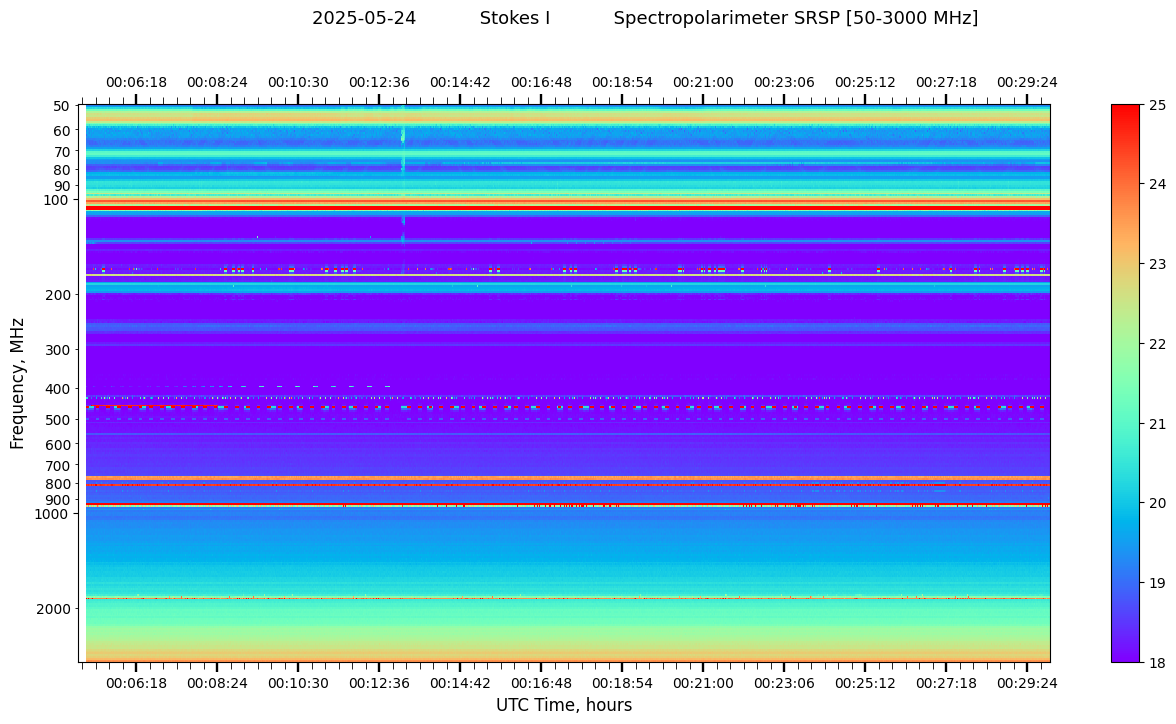

17213

In [45]:
# Time interval for plot
[tobsststr, tobsedstr] = ['00:05:00', '00:30:00'] # [Start observation time, End observation time]

[tobsst, tobsed] = to_ticks(tobsststr, tobsedstr)
st_obs, end_obs = np.argwhere(time_axis >= tobsst)[0][0], np.argwhere(time_axis >= tobsed)[0][0]

t_st = int(tobsststr[0:2]) + round(int(tobsststr[3:5]) / 60, 2)
t_ed = int(tobsedstr[0:2]) + round(int(tobsedstr[3:5]) / 60, 2)

# Plot
plt.ioff()
freq_st = 0 
freq_end = 295

fig = plt.figure(figsize = (13.5,7.25))
fig.subplots_adjust(wspace=0, hspace=0,left = 0.08, right = 0.98, top = 0.85, bottom = 0.08)
fig.tight_layout()
sub1 = fig.add_subplot(1, 1, 1);


pic1 = sub1.pcolormesh(time_axis[st_obs:end_obs] - 3600*3, freqs[freq_st:freq_end], np.log(dataI[freq_st:freq_end][:, st_obs:end_obs]),

            cmap="rainbow",
            shading=None, #'flat','nearest','gouraud','auto'
            vmin = 18,
            vmax = 25,
            )

ax = plt.gca()

ax.set_xlim(3600 * t_st, 3600 * t_ed)
dt_major = 1200
dt_minor = dt_major / 6

coff_dt = tics_coff_dt(t_st, t_ed)

ax.tick_params(axis='x', 
               which='both', 
               length=5, 
               # direction='inout', 
               labeltop=True, 
               top=True,
              )

ax.xaxis.set_major_locator(plt.MultipleLocator(dt_major * coff_dt));
ax.xaxis.set_major_formatter(plt.FuncFormatter(hhmm_format));
ax.xaxis.set_minor_locator(plt.MultipleLocator(dt_minor * coff_dt));

ax.tick_params(axis='x', 
               which='major', 
               length=7, 
               width=1.7, 
               # labelsize=8,
              )

ax.invert_yaxis()
plt.yscale('log')

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
ax.yaxis.set_minor_formatter(StrMethodFormatter('{x:.0f}'))

sub1.set_xlabel("UTC Time, hours",fontsize=12)
sub1.set_ylabel("Frequency, MHz",fontsize=12)
fig.suptitle(date + "           Stokes I           Spectropolarimeter SRSP [50-3000 MHz]", fontsize=13, y = 0.98)

cbar = fig.colorbar(pic1)

plt.show()
gc.collect()